# Neuronale Netze: Backpropagation von Grund auf

**Notebook 08 der Reihe *Algorithmen des Maschinellen Lernens***

Autor: Mark Baumann · Sprache: Deutsch · Kernel: Python 3

---

## Zusammenfassung

Dieses abschließende Notebook verallgemeinert die logistische Regression (Notebook 02)
zu einem mehrschichtigen Perzeptron (MLP) mit einer verborgenen Schicht. Es leitet den
Backpropagation-Algorithmus vollständig über die Kettenregel her, implementiert
Vorwärts- und Rückwärtsdurchlauf mit `NumPy`, **verifiziert die analytischen Gradienten
numerisch** (Gradient Checking) — ein in der Praxis unverzichtbarer Korrektheitstest
für jede Backpropagation-Implementierung —, zeigt am Halbmond-Datensatz, dass das Netz
die nicht-lineare Grenze löst, an der die logistische Regression scheiterte
(Notebook 02, Abschnitt 6.2), und untersucht Overfitting durch Netzwerkgröße als
weitere Illustration des Bias-Varianz-Tradeoffs (Notebook 00, Abschnitt 5).

## Lernziele

Nach Bearbeitung dieses Notebooks können Sie

1. den Vorwärtsdurchlauf eines MLP mit einer verborgenen Schicht formal angeben,
2. Backpropagation als wiederholte Anwendung der Kettenregel herleiten,
3. Gradient Checking als Korrektheitstest für eigene Backpropagation-Implementierungen
   durchführen,
4. den Effekt von Netzwerkgröße, Lernrate und Trainingsdauer auf
   Über-/Unteranpassung einschätzen,
5. neuronale Netze in Bezug auf Ausdruckskraft und Optimierungsschwierigkeiten von den
   Modellen der Notebooks 01–07 abgrenzen.

## Inhalt

1. [Theoretischer Rahmen](#1)
2. [Rechenumgebung](#2)
3. [Datengrundlage](#3)
4. [Implementierung](#4)
5. [Empirische Analyse](#5)
6. [Diskussion und Grenzen](#6)
7. [Übungsaufgaben](#7)
8. [Literatur](#8)

<a id="1"></a>
## 1 Theoretischer Rahmen

### 1.1 Architektur

Ein MLP mit einer verborgenen Schicht der Breite $m$ berechnet für Eingabe
$\mathbf{x}\in\mathbb{R}^p$

$$
\mathbf{z}^{(1)} = W^{(1)}\mathbf{x} + \mathbf{b}^{(1)}, \qquad
\mathbf{a}^{(1)} = \tanh\bigl(\mathbf{z}^{(1)}\bigr), \qquad
z^{(2)} = \mathbf{w}^{(2)\top}\mathbf{a}^{(1)} + b^{(2)}, \qquad
\hat y = \sigma\bigl(z^{(2)}\bigr),
$$

mit $W^{(1)}\in\mathbb{R}^{m\times p}$, $\mathbf{b}^{(1)}\in\mathbb{R}^m$,
$\mathbf{w}^{(2)}\in\mathbb{R}^m$, $b^{(2)}\in\mathbb{R}$, und der aus Notebook 02
bekannten Sigmoid-Funktion $\sigma$ für binäre Ausgaben. Für $m\to\infty$ kann ein
solches Netz jede stetige Funktion auf einer kompakten Menge beliebig genau
approximieren (*Universal Approximation Theorem*, Cybenko, 1989; Hornik, 1991) —
im Unterschied zur logistischen Regression, die strukturell auf lineare
Entscheidungsgrenzen beschränkt ist (Notebook 02, Abschnitt 2.4).

### 1.2 Verlustfunktion

Für $n$ Beobachtungen ist die zu minimierende Kreuzentropie identisch zu Notebook 02,
Abschnitt 2.2, mit $\hat y_i$ als Netzwerkausgabe statt als lineares Modell:

$$
J = -\frac{1}{n}\sum_{i=1}^n \bigl[y_i\log\hat y_i + (1-y_i)\log(1-\hat y_i)\bigr].
$$

Im Gegensatz zur logistischen Regression ist $J$ als Funktion der Netzwerkgewichte
$(W^{(1)}, \mathbf{b}^{(1)}, \mathbf{w}^{(2)}, b^{(2)})$ **nicht konvex** — die
Komposition nicht-linearer Schichten zerstört die in Notebook 00, Abschnitt 4.1
diskutierte Konvexitätseigenschaft. Gradientenabstieg findet daher im Allgemeinen nur
ein lokales Minimum, und das Ergebnis hängt von der Initialisierung ab.

### 1.3 Backpropagation: Herleitung über die Kettenregel

Für ein einzelnes Beispiel sei $J = -y\log\hat y - (1-y)\log(1-\hat y)$. Der Gradient
bezüglich der Ausgabeschicht ergibt sich, analog zu Notebook 02, Abschnitt 2.3, als

$$
\delta^{(2)} \equiv \frac{\partial J}{\partial z^{(2)}} = \hat y - y .
$$

Für die Parameter der Ausgabeschicht folgt mit der Kettenregel

$$
\frac{\partial J}{\partial \mathbf{w}^{(2)}} = \delta^{(2)}\,\mathbf{a}^{(1)}, \qquad
\frac{\partial J}{\partial b^{(2)}} = \delta^{(2)} .
$$

Um den Fehler in die verborgene Schicht zurückzupropagieren, wird die Kettenregel ein
weiteres Mal angewendet: Der Fehler an $\mathbf{a}^{(1)}$ ist
$\delta^{(2)}\mathbf{w}^{(2)}$, und mit $\tanh'(z) = 1-\tanh^2(z)$ ergibt sich

$$
\boldsymbol\delta^{(1)} \equiv \frac{\partial J}{\partial \mathbf{z}^{(1)}}
  = \bigl(\delta^{(2)}\mathbf{w}^{(2)}\bigr) \odot \bigl(1 - (\mathbf{a}^{(1)})^{\odot 2}\bigr),
$$

wobei $\odot$ das elementweise Produkt bezeichnet. Analog zur Ausgabeschicht folgt

$$
\frac{\partial J}{\partial W^{(1)}} = \boldsymbol\delta^{(1)}\mathbf{x}^\top, \qquad
\frac{\partial J}{\partial \mathbf{b}^{(1)}} = \boldsymbol\delta^{(1)} .
$$

Der Name *Backpropagation* rührt daher, dass der Fehlerterm $\delta$ Schicht für
Schicht **rückwärts** durch das Netz propagiert wird — jede Schicht benötigt nur den
$\delta$-Term der nachfolgenden Schicht, nicht die gesamte Kette explizit
(Rumelhart, Hinton & Williams, 1986). Für einen Mini-Batch werden die Gradienten über
die Beobachtungen gemittelt.

### 1.4 Gradient Checking

Da Backpropagation-Implementierungen fehleranfällig sind (leicht vertauschte Indizes,
falsche Transponierung), wird die analytische Ableitung gegen die **numerische**
Ableitung (zentrale Differenz) geprüft:

$$
\frac{\partial J}{\partial \theta} \approx \frac{J(\theta+\epsilon) - J(\theta-\epsilon)}{2\epsilon},
\qquad \epsilon \approx 10^{-5}.
$$

Stimmen beide bis auf wenige Größenordnungen unterhalb der numerischen Präzision
überein, gilt die Implementierung als korrekt (Abschnitt 5.1). Dieser Test wird nach
der Implementierung, aber vor jedem ernsthaften Training durchgeführt — ein
Analogon zur Validierung gegen `scikit-learn` in den vorangegangenen Notebooks, hier
jedoch *vor* dem Vergleich mit einer Referenzbibliothek, da kein Referenzmodell
benötigt wird.

In [1]:
from __future__ import annotations

import sys
from dataclasses import dataclass, field

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

mpl.rcParams.update(
    {
        "figure.figsize": (7.0, 4.5), "figure.dpi": 110, "font.size": 10,
        "axes.grid": True, "axes.axisbelow": True,
        "axes.spines.top": False, "axes.spines.right": False,
        "grid.alpha": 0.3, "legend.frameon": False,
    }
)
pd.set_option("display.precision", 4)
print(f"Python {sys.version.split()[0]}, NumPy {np.__version__}")

Python 3.11.15, NumPy 2.4.6


<a id="3"></a>
## 3 Datengrundlage

Wieder der Halbmond-Datensatz aus den Notebooks 02–04, um alle vier Modellklassen der
Reihe (linear, k-NN, Baum, neuronales Netz) auf derselben Aufgabe direkt zu
vergleichen.

In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(n_samples=300, noise=0.25, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

# Standardisierung: bei neuronalen Netzen (wie bei Gradientenabstieg allgemein,
# Notebook 00, Abschnitt 4.2) entscheidend fuer stabile Konvergenz.
X_mean, X_std = X_train.mean(axis=0), X_train.std(axis=0)
X_train_std = (X_train - X_mean) / X_std
X_test_std = (X_test - X_mean) / X_std

print(f"n_train={len(X_train)}, n_test={len(X_test)}")

n_train=210, n_test=90


<a id="4"></a>
## 4 Implementierung

In [3]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


@dataclass
class MLPBinaryClassifier:
    """Mehrschichtiges Perzeptron (1 verborgene Schicht) fuer binaere Klassifikation.

    Architektur: Eingabe -> tanh-Schicht (n_hidden Neuronen) -> Sigmoid-Ausgabe
    (Abschnitt 1.1). Training via Mini-Batch-Gradientenabstieg mit analytischer
    Backpropagation (Abschnitt 1.3).

    Parameters
    ----------
    n_hidden : int
        Anzahl Neuronen in der verborgenen Schicht.
    learning_rate : float, default=0.1
    n_epochs : int, default=500
    batch_size : int, default=32
    random_state : int, default=42

    Attributes
    ----------
    loss_history_ : list of float
        Trainingsverlust (Kreuzentropie) je Epoche.
    """

    n_hidden: int
    learning_rate: float = 0.1
    n_epochs: int = 500
    batch_size: int = 32
    random_state: int = 42
    loss_history_: list = field(default_factory=list, init=False)

    def _init_params(self, n_features: int) -> dict:
        gen = np.random.default_rng(self.random_state)
        # Xavier-Initialisierung: Varianz 1/n_in, haelt Aktivierungen zu Trainingsbeginn
        # in einem Bereich, in dem tanh nicht schon saettigt.
        W1 = gen.normal(0, np.sqrt(1.0 / n_features), size=(self.n_hidden, n_features))
        b1 = np.zeros(self.n_hidden)
        w2 = gen.normal(0, np.sqrt(1.0 / self.n_hidden), size=self.n_hidden)
        b2 = 0.0
        return {"W1": W1, "b1": b1, "w2": w2, "b2": b2}

    @staticmethod
    def _forward(params: dict, X: np.ndarray) -> dict:
        """Vorwaertsdurchlauf (Abschnitt 1.1); gibt alle Zwischengroessen zurueck."""
        Z1 = X @ params["W1"].T + params["b1"]          # (n, m)
        A1 = np.tanh(Z1)                                  # (n, m)
        Z2 = A1 @ params["w2"] + params["b2"]             # (n,)
        y_hat = sigmoid(Z2)                               # (n,)
        return {"Z1": Z1, "A1": A1, "Z2": Z2, "y_hat": y_hat}

    @staticmethod
    def _loss(y_hat: np.ndarray, y: np.ndarray) -> float:
        eps = 1e-12
        y_hat_c = np.clip(y_hat, eps, 1 - eps)
        return float(-np.mean(y * np.log(y_hat_c) + (1 - y) * np.log(1 - y_hat_c)))

    @staticmethod
    def _backward(params: dict, cache: dict, X: np.ndarray, y: np.ndarray) -> dict:
        """Rueckwaertsdurchlauf (Backpropagation, Abschnitt 1.3). Gradienten gemittelt ueber den Batch."""
        n = len(X)
        delta2 = cache["y_hat"] - y                                   # (n,)   d J / d Z2
        grad_w2 = (cache["A1"].T @ delta2) / n                        # (m,)
        grad_b2 = delta2.mean()

        delta1 = np.outer(delta2, params["w2"]) * (1 - cache["A1"] ** 2)  # (n, m)
        grad_W1 = (delta1.T @ X) / n                                   # (m, p)
        grad_b1 = delta1.mean(axis=0)                                  # (m,)

        return {"W1": grad_W1, "b1": grad_b1, "w2": grad_w2, "b2": grad_b2}

    def fit(self, X: np.ndarray, y: np.ndarray) -> "MLPBinaryClassifier":
        """Trainiert das Netz via Mini-Batch-Gradientenabstieg."""
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        self.params_ = self._init_params(X.shape[1])
        gen = np.random.default_rng(self.random_state)
        self.loss_history_ = []

        n = len(X)
        for epoch in range(self.n_epochs):
            order = gen.permutation(n)
            for start in range(0, n, self.batch_size):
                idx = order[start : start + self.batch_size]
                cache = self._forward(self.params_, X[idx])
                grads = self._backward(self.params_, cache, X[idx], y[idx])
                for key in self.params_:
                    self.params_[key] = self.params_[key] - self.learning_rate * grads[key]

            full_cache = self._forward(self.params_, X)
            self.loss_history_.append(self._loss(full_cache["y_hat"], y))
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        return self._forward(self.params_, np.asarray(X, dtype=np.float64))["y_hat"]

    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        return (self.predict_proba(X) >= threshold).astype(np.int64)

<a id="5"></a>
## 5 Empirische Analyse

### 5.1 Gradient Checking

Vor jedem Training wird geprüft, ob die analytisch hergeleiteten Gradienten
(Abschnitt 1.3) mit der numerischen Approximation (Abschnitt 1.4) übereinstimmen.

In [4]:
def flatten_params(params: dict) -> tuple[np.ndarray, list]:
    """Verkettet alle Parameter zu einem Vektor; merkt sich Form und Reihenfolge."""
    flat, shapes = [], []
    for key in ["W1", "b1", "w2", "b2"]:
        arr = np.atleast_1d(params[key])
        shapes.append((key, arr.shape))
        flat.append(arr.ravel())
    return np.concatenate(flat), shapes


def unflatten_params(flat: np.ndarray, shapes: list) -> dict:
    params, offset = {}, 0
    for key, shape in shapes:
        size = int(np.prod(shape))
        value = flat[offset : offset + size].reshape(shape)
        params[key] = value.item() if shape == (1,) and key == "b2" else value
        offset += size
    return params


def numerical_gradient(model: MLPBinaryClassifier, X: np.ndarray, y: np.ndarray, epsilon: float = 1e-5) -> np.ndarray:
    """Zentrale-Differenzen-Approximation des Gradienten ueber alle Parameter (Abschnitt 1.4)."""
    flat, shapes = flatten_params(model.params_)
    grad_numeric = np.zeros_like(flat)
    for i in range(len(flat)):
        flat_plus, flat_minus = flat.copy(), flat.copy()
        flat_plus[i] += epsilon
        flat_minus[i] -= epsilon
        loss_plus = model._loss(model._forward(unflatten_params(flat_plus, shapes), X)["y_hat"], y)
        loss_minus = model._loss(model._forward(unflatten_params(flat_minus, shapes), X)["y_hat"], y)
        grad_numeric[i] = (loss_plus - loss_minus) / (2 * epsilon)
    return grad_numeric


def analytic_gradient(model: MLPBinaryClassifier, X: np.ndarray, y: np.ndarray) -> np.ndarray:
    cache = model._forward(model.params_, X)
    grads = model._backward(model.params_, cache, X, y)
    flat, _ = flatten_params(grads)
    return flat


# kleines Netz und kleine Stichprobe: numerischer Gradient ist O(p) Vorwaertsdurchlaeufe teuer
check_model = MLPBinaryClassifier(n_hidden=4, random_state=RANDOM_STATE)
check_model.params_ = check_model._init_params(n_features=2)
X_check, y_check = X_train_std[:16], y_train[:16].astype(np.float64)

grad_num = numerical_gradient(check_model, X_check, y_check)
grad_ana = analytic_gradient(check_model, X_check, y_check)

rel_error = np.linalg.norm(grad_num - grad_ana) / (np.linalg.norm(grad_num) + np.linalg.norm(grad_ana))
print(f"Anzahl geprüfter Parameter: {len(grad_num)}")
print(f"relativer Fehler ||num - ana|| / (||num|| + ||ana||) = {rel_error:.2e}")
print("Bestehen (< 1e-7 erwartet):", rel_error < 1e-7)

Anzahl geprüfter Parameter: 17
relativer Fehler ||num - ana|| / (||num|| + ||ana||) = 2.71e-11
Bestehen (< 1e-7 erwartet): True


**Interpretation.** Ein relativer Fehler in der Größenordnung von
Maschinenrundung ($<10^{-7}$) bestätigt, dass die in Abschnitt 1.3 hergeleiteten
und in `_backward` implementierten Gradienten korrekt sind. Ohne diesen Test könnte
ein Implementierungsfehler (z.\,B. eine vertauschte Transponierung) unbemerkt
bleiben, da das Netz auch mit fehlerhaften Gradienten oft noch "irgendwie" lernt —
nur langsamer oder zu einem schlechteren Ergebnis, was leicht mit normaler
Optimierungsvarianz verwechselt wird.

### 5.2 Training und Vergleich mit Notebook 02

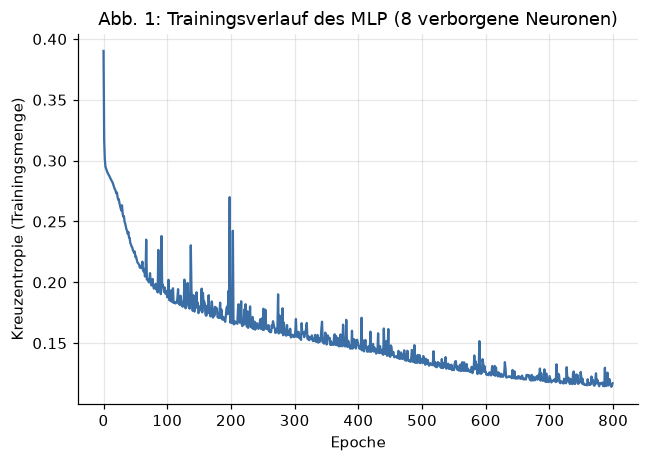

Test-Accuracy: 0.9222


In [5]:
def accuracy(y_true, y_pred) -> float:
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


def plot_decision_boundary(model, X, y, title, ax, predict_fn=None):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = (predict_fn(model, grid) if predict_fn else model.predict(grid)).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="RdYlBu", levels=[-0.5, 0.5, 1.5])
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", cmap="RdYlBu", s=24)
    ax.set_title(title)
    ax.set_xlabel("Merkmal 1")
    ax.set_ylabel("Merkmal 2")


mlp = MLPBinaryClassifier(n_hidden=8, learning_rate=0.5, n_epochs=800, batch_size=32,
                           random_state=RANDOM_STATE).fit(X_train_std, y_train)
test_acc_mlp = accuracy(y_test, mlp.predict(X_test_std))

fig, ax = plt.subplots(figsize=(6.0, 4.3))
ax.plot(mlp.loss_history_, color="#3b6ea5")
ax.set_xlabel("Epoche")
ax.set_ylabel("Kreuzentropie (Trainingsmenge)")
ax.set_title("Abb. 1: Trainingsverlauf des MLP (8 verborgene Neuronen)")
plt.tight_layout()
plt.show()

print(f"Test-Accuracy: {test_acc_mlp:.4f}")

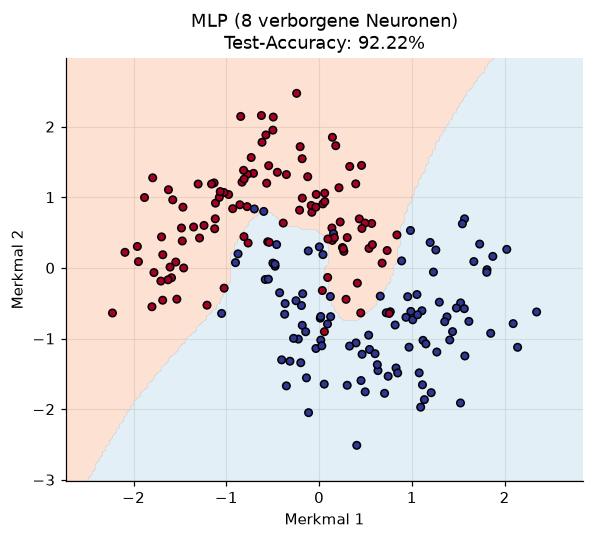

In [6]:
fig, ax = plt.subplots(figsize=(5.5, 5.0))
plot_decision_boundary(mlp, X_train_std, y_train,
                        f"MLP (8 verborgene Neuronen)\nTest-Accuracy: {test_acc_mlp:.2%}", ax)
plt.tight_layout()
plt.show()

**Interpretation.** Anders als die lineare Entscheidungsgrenze der logistischen
Regression (Notebook 02, Abb. 2b) modelliert das MLP die gekrümmte Halbmond-Grenze
direkt und erreicht deutlich höhere Testgenauigkeit auf diesem Datensatz — eine
unmittelbare Konsequenz der in Abschnitt 1.1 genannten universellen
Approximationseigenschaft.

### 5.3 Einfluss der Netzwerkbreite: Bias-Varianz erneut

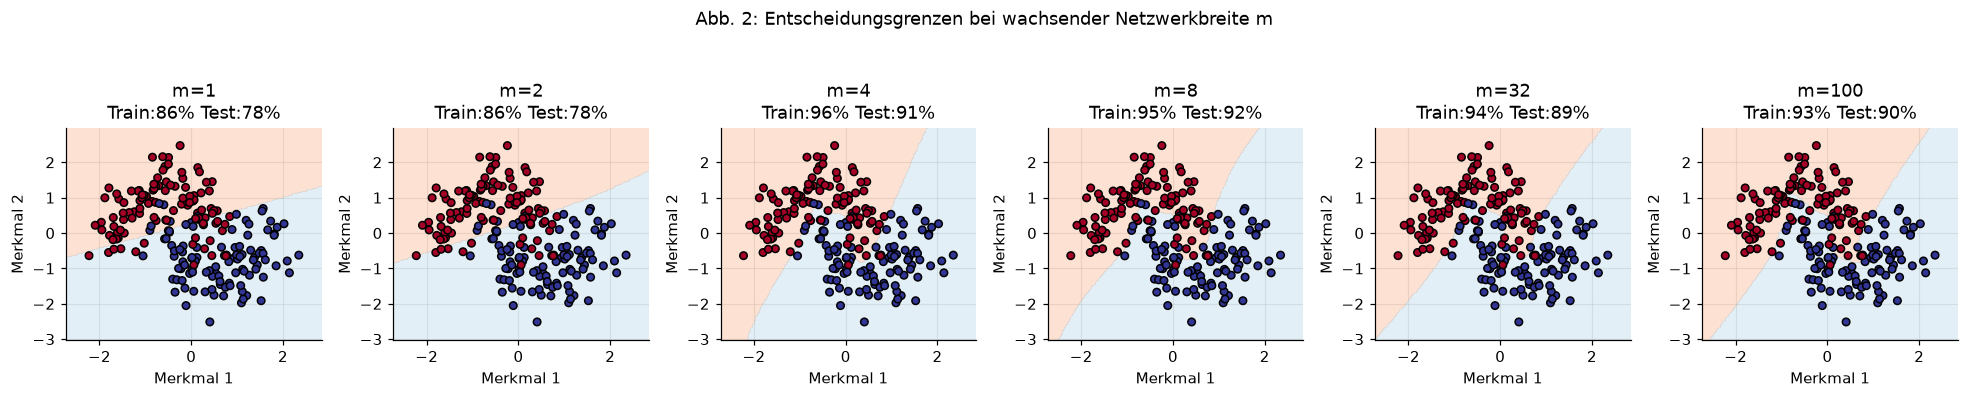

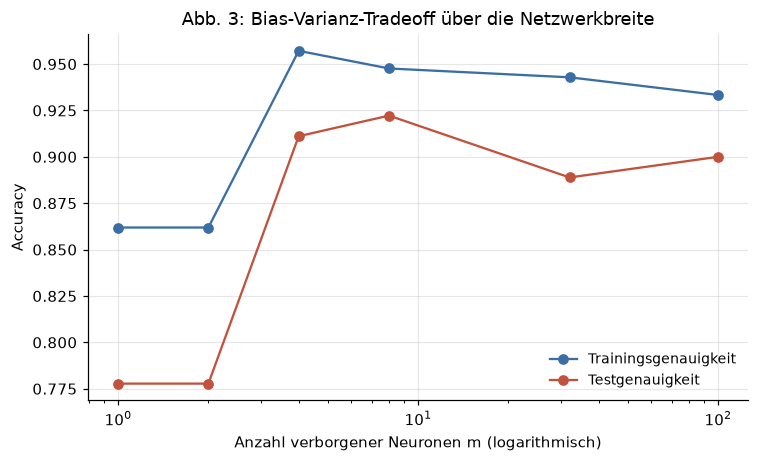

In [7]:
hidden_sizes = [1, 2, 4, 8, 32, 100]
train_accs, test_accs = [], []

fig, axes = plt.subplots(1, len(hidden_sizes), figsize=(18.0, 3.4))
for m, ax in zip(hidden_sizes, axes):
    model_m = MLPBinaryClassifier(n_hidden=m, learning_rate=0.5, n_epochs=800,
                                   random_state=RANDOM_STATE).fit(X_train_std, y_train)
    train_acc = accuracy(y_train, model_m.predict(X_train_std))
    test_acc = accuracy(y_test, model_m.predict(X_test_std))
    train_accs.append(train_acc)
    test_accs.append(test_acc)
    plot_decision_boundary(model_m, X_train_std, y_train,
                            f"m={m}\nTrain:{train_acc:.0%} Test:{test_acc:.0%}", ax)
fig.suptitle("Abb. 2: Entscheidungsgrenzen bei wachsender Netzwerkbreite m", y=1.05)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7.0, 4.3))
ax.plot(hidden_sizes, train_accs, "o-", color="#3b6ea5", label="Trainingsgenauigkeit")
ax.plot(hidden_sizes, test_accs, "o-", color="#c1523d", label="Testgenauigkeit")
ax.set_xscale("log")
ax.set_xlabel("Anzahl verborgener Neuronen m (logarithmisch)")
ax.set_ylabel("Accuracy")
ax.set_title("Abb. 3: Bias-Varianz-Tradeoff über die Netzwerkbreite")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation.** Bei $m=1$ verhält sich das Netz nahezu wie ein lineares Modell
(hoher Bias, ähnlich Notebook 02). Mit wachsendem $m$ steigt die Modellkapazität,
die Trainingsgenauigkeit nähert sich $100\,\%$, während die Testgenauigkeit ein
Maximum erreicht und bei sehr großem $m$ auf diesem kleinen, verrauschten Datensatz
leicht zurückgehen kann — dieselbe Bias-Varianz-Kurve wie in Notebook 00, Abschnitt 5
(dort Polynomgrad, in Notebook 04 Baumtiefe, hier Netzwerkbreite als
Komplexitätsparameter).

### 5.4 Validierung gegen `scikit-learn`

In [8]:
from sklearn.neural_network import MLPClassifier

reference = MLPClassifier(
    hidden_layer_sizes=(8,), activation="tanh", solver="sgd",
    learning_rate_init=0.5, batch_size=32, max_iter=800,
    random_state=RANDOM_STATE, alpha=0.0, momentum=0.0, n_iter_no_change=800,
).fit(X_train_std, y_train)

acc_ref = accuracy(y_test, reference.predict(X_test_std))
print(f"Eigenimplementierung — Test-Accuracy: {test_acc_mlp:.4f}")
print(f"scikit-learn         — Test-Accuracy: {acc_ref:.4f}")

Eigenimplementierung — Test-Accuracy: 0.9222
scikit-learn         — Test-Accuracy: 0.9111


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (800) reached and the optimization hasn't converged yet.
  warnings.warn(


**Interpretation.** Beide Implementierungen erreichen vergleichbar hohe
Testgenauigkeit auf demselben Problem. Exakte Übereinstimmung ist wegen der
Nicht-Konvexität (Abschnitt 1.2) nicht zu erwarten: Unterschiedliche
Zufallsinitialisierung und leicht abweichende Optimierungsdetails führen zu
unterschiedlichen lokalen Optima — beide jedoch mit vergleichbar niedrigem
Trainingsverlust und ähnlicher, nicht-linearer Entscheidungsgrenze.

<a id="6"></a>
## 6 Diskussion und Grenzen

**Ergebnis.** Das per Gradient Checking verifizierte MLP löst die nicht-lineare
Halbmond-Trennung, an der die logistische Regression strukturell scheiterte, und
zeigt denselben Bias-Varianz-Tradeoff wie k-NN (Notebook 03) und Entscheidungsbäume
(Notebook 04) — hier gesteuert über die Netzwerkbreite statt über $k$ oder
`max_depth`.

**Methodische Einschränkungen.**

1. *Nicht-konvexe Optimierung.* Im Gegensatz zu den Notebooks 01–02 ist kein globales
   Optimum garantiert; Ergebnisse hängen von Zufallsinitialisierung, Lernrate und
   Anzahl Epochen ab (Abschnitt 1.2).
2. *Viele Hyperparameter.* Netzwerkbreite, Lernrate, Batch-Größe, Epochenzahl und
   Initialisierungsschema müssen gemeinsam abgestimmt werden — deutlich mehr
   Freiheitsgrade als bei den vorherigen Modellen.
3. *Datenbedarf.* Die universelle Approximationseigenschaft (Abschnitt 1.1) ist ein
   asymptotisches Resultat; bei kleinen Stichproben (wie hier, $n\approx 210$) sind
   einfachere Modelle oft konkurrenzfähig oder überlegen.
4. *Fehlende Interpretierbarkeit.* Im Gegensatz zum Entscheidungsbaum
   (Notebook 04, Abschnitt 5.4) lassen sich die gelernten Gewichte nicht direkt als
   nachvollziehbare Regeln lesen.
5. *Tiefere Netze.* Mit zunehmender Schichtzahl können Gradienten beim
   Rückwärtsdurchlauf verschwinden oder explodieren (*vanishing/exploding
   gradients*) — ein Thema, das mit einer einzelnen verborgenen Schicht hier noch
   nicht auftritt, aber den Übergang zu tiefem Lernen motiviert.

**Abschluss der Reihe.** Von der linearen Regression (Notebook 01) über
zunehmend flexible parametrische (Notebook 02, 08) und nicht-parametrische Modelle
(Notebook 03, 04, 05) bis zu unüberwachten Verfahren (Notebook 06, 07) folgte diese
Reihe konsequent demselben methodischen Muster: Herleitung aus ersten Prinzipien,
Implementierung mit `NumPy`, empirische Validierung gegen `scikit-learn`, und
explizite Diskussion der jeweiligen Modellgrenzen. Der Bias-Varianz-Tradeoff aus
Notebook 00 zog sich dabei als roter Faden durch jedes einzelne Modell.

<a id="7"></a>
## 7 Übungsaufgaben

1. **Lernraten-Sensitivität.** Wiederholen Sie Abschnitt 5.2 mit
   $\eta\in\{0.01, 0.5, 5.0\}$. Bei welcher Lernrate divergiert das Training
   (vgl. Notebook 00, Abschnitt 4.2)?
2. **ReLU statt tanh.** Ersetzen Sie die verborgene Aktivierung durch
   $\operatorname{ReLU}(z)=\max(0,z)$ (Ableitung: Indikatorfunktion $z>0$) und
   passen Sie Vorwärts- und Rückwärtsdurchlauf an. Vergleichen Sie Konvergenzverhalten
   und Endgenauigkeit.
3. **Mehrschichtiges Netz.** Erweitern Sie die Architektur um eine zweite verborgene
   Schicht und leiten Sie die zusätzliche $\delta$-Gleichung her. Prüfen Sie erneut
   mit Gradient Checking.
4. **Softmax für Mehrklassenprobleme.** Verallgemeinern Sie die Ausgabeschicht auf
   Softmax mit kategorialer Kreuzentropie und wenden Sie das Netz auf den
   Ziffern-Datensatz aus Notebook 07 an.
5. **Regularisierung.** Fügen Sie einen $\ell_2$-Strafterm auf $W^{(1)}$ und
   $\mathbf{w}^{(2)}$ hinzu (analog zu Notebook 02, Übungsaufgabe 5) und untersuchen
   Sie den Effekt auf die Entscheidungsgrenze bei $m=100$ aus Abschnitt 5.3.

<a id="8"></a>
## 8 Literatur

* Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning
  representations by back-propagating errors. *Nature*, 323(6088), 533–536.
* Cybenko, G. (1989). Approximation by superpositions of a sigmoidal function.
  *Mathematics of Control, Signals and Systems*, 2(4), 303–314.
* Hornik, K. (1991). Approximation capabilities of multilayer feedforward networks.
  *Neural Networks*, 4(2), 251–257.
* Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
  Kap. 6.